# Import Libraries

In [0]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

In [0]:
import matplotlib.pyplot as plt
import pandas as pd

# Loading the Data

In [0]:
patients = spark.read \
    .option("header", True) \
    .option("inferSchema", True) \
    .csv("/Volumes/dbacademy/default/tutorials/patients.csv")

In [0]:
patients.show(5)

+----------+----------+---------+------+-------------+--------------+------------+-----------------+------------------+----------------+--------------------+
|patient_id|first_name|last_name|gender|date_of_birth|contact_number|     address|registration_date|insurance_provider|insurance_number|               email|
+----------+----------+---------+------+-------------+--------------+------------+-----------------+------------------+----------------+--------------------+
|      P001|     David| Williams|     F|   1955-06-04|    6939585183| 789 Pine Rd|       2022-06-23|      WellnessCorp|       INS840674|david.williams@ma...|
|      P002|     Emily|    Smith|     F|   1984-10-12|    8228188767|321 Maple Dr|       2022-01-15|       PulseSecure|       INS354079|emily.smith@mail.com|
|      P003|     Laura|    Jones|     M|   1977-08-21|    8397029847|321 Maple Dr|       2022-02-07|       PulseSecure|       INS650929|laura.jones@mail.com|
|      P004|   Michael|  Johnson|     F|   1981-02-2

In [0]:
doctors = spark.read \
    .option("header", True) \
    .option("inferSchema", True) \
    .csv("/Volumes/dbacademy/default/tutorials/doctors.csv")

appointments = spark.read \
    .option("header", True) \
    .option("inferSchema", True) \
    .csv("/Volumes/dbacademy/default/tutorials/appointments.csv")

treatments = spark.read \
    .option("header", True) \
    .option("inferSchema", True) \
    .csv("/Volumes/dbacademy/default/tutorials/treatments.csv")

billing = spark.read \
    .option("header", True) \
    .option("inferSchema", True) \
    .csv("/Volumes/dbacademy/default/tutorials/billing.csv")

### Check the data

In [0]:
doctors.show(5)
appointments.show(5)
treatments.show(5)
billing.show(5)

+---------+----------+---------+--------------+------------+----------------+----------------+--------------------+
|doctor_id|first_name|last_name|specialization|phone_number|years_experience| hospital_branch|               email|
+---------+----------+---------+--------------+------------+----------------+----------------+--------------------+
|     D001|     David|   Taylor|   Dermatology|  8322010158|              17| Westside Clinic|dr.david.taylor@h...|
|     D002|      Jane|    Davis|    Pediatrics|  9004382050|              24| Eastside Clinic|dr.jane.davis@hos...|
|     D003|      Jane|    Smith|    Pediatrics|  8737740598|              19| Eastside Clinic|dr.jane.smith@hos...|
|     D004|     David|    Jones|    Pediatrics|  6594221991|              28|Central Hospital|dr.david.jones@ho...|
|     D005|     Sarah|   Taylor|   Dermatology|  9118538547|              26|Central Hospital|dr.sarah.taylor@h...|
+---------+----------+---------+--------------+------------+------------

### Check the Schema

In [0]:
patients.printSchema()
doctors.printSchema()
appointments.printSchema()
treatments.printSchema()
billing.printSchema()

root
 |-- patient_id: string (nullable = true)
 |-- first_name: string (nullable = true)
 |-- last_name: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- date_of_birth: date (nullable = true)
 |-- contact_number: long (nullable = true)
 |-- address: string (nullable = true)
 |-- registration_date: date (nullable = true)
 |-- insurance_provider: string (nullable = true)
 |-- insurance_number: string (nullable = true)
 |-- email: string (nullable = true)

root
 |-- doctor_id: string (nullable = true)
 |-- first_name: string (nullable = true)
 |-- last_name: string (nullable = true)
 |-- specialization: string (nullable = true)
 |-- phone_number: long (nullable = true)
 |-- years_experience: integer (nullable = true)
 |-- hospital_branch: string (nullable = true)
 |-- email: string (nullable = true)

root
 |-- appointment_id: string (nullable = true)
 |-- patient_id: string (nullable = true)
 |-- doctor_id: string (nullable = true)
 |-- appointment_date: date (nullable 

### Basic Data Analysis

In [0]:
#Missing Values
def missing_values(df):
    return df.select([
        F.sum(F.col(c).isNull().cast("int")).alias(c)
        for c in df.columns
    ])

missing_values(patients).show()
missing_values(doctors).show()
missing_values(appointments).show()
missing_values(treatments).show()
missing_values(billing).show()

+----------+----------+---------+------+-------------+--------------+-------+-----------------+------------------+----------------+-----+
|patient_id|first_name|last_name|gender|date_of_birth|contact_number|address|registration_date|insurance_provider|insurance_number|email|
+----------+----------+---------+------+-------------+--------------+-------+-----------------+------------------+----------------+-----+
|         0|         0|        0|     0|            0|             0|      0|                0|                 0|               0|    0|
+----------+----------+---------+------+-------------+--------------+-------+-----------------+------------------+----------------+-----+

+---------+----------+---------+--------------+------------+----------------+---------------+-----+
|doctor_id|first_name|last_name|specialization|phone_number|years_experience|hospital_branch|email|
+---------+----------+---------+--------------+------------+----------------+---------------+-----+
|        

In [0]:
# Duplicate Records
print("Patient duplicates:",
      patients.count() - patients.dropDuplicates(["PATIENT_ID"]).count())

print("Doctor duplicates:",
      doctors.count() - doctors.dropDuplicates(["DOCTOR_ID"]).count())

print("Appointment duplicates:",
      appointments.count() - appointments.dropDuplicates(["APPOINTMENT_ID"]).count())

print("Treatment duplicates:",
      treatments.count() - treatments.dropDuplicates(["TREATMENT_ID"]).count())

print("Billing duplicates:",
      billing.count() - billing.dropDuplicates(["BILL_ID"]).count())

Patient duplicates: 0
Doctor duplicates: 0
Appointment duplicates: 0
Treatment duplicates: 0
Billing duplicates: 0


# Descriptive Analaysis

In [0]:
print("Total Patients:", patients.select("PATIENT_ID").distinct().count())
print("Total Doctors:", doctors.select("DOCTOR_ID").distinct().count())
print("Total Appointments:", appointments.select("APPOINTMENT_ID").distinct().count())
print("Total Treatments:", treatments.select("TREATMENT_ID").distinct().count())
print("Total Bills:", billing.select("BILL_ID").distinct().count())

Total Patients: 50
Total Doctors: 10
Total Appointments: 200
Total Treatments: 200
Total Bills: 200


## Patient Analysis

### Gender Distribution

In [0]:
gender_distribution = (
    patients
    .groupBy("GENDER")
    .agg(F.countDistinct("PATIENT_ID").alias("Patient_Count"))
    .orderBy(F.desc("Patient_Count"))
)

gender_distribution.show()

+------+-------------+
|GENDER|Patient_Count|
+------+-------------+
|     M|           31|
|     F|           19|
+------+-------------+



### Patients by Insurance Provider 

In [0]:
insurance_analysis = (
    patients
    .groupBy("INSURANCE_PROVIDER")
    .agg(
        F.countDistinct("PATIENT_ID").alias("Patient_Count")
    )
    .orderBy(F.desc("Patient_Count"))
)

insurance_analysis.show()

+------------------+-------------+
|INSURANCE_PROVIDER|Patient_Count|
+------------------+-------------+
|      MedCare Plus|           18|
|      WellnessCorp|           16|
|       PulseSecure|           10|
|       HealthIndia|            6|
+------------------+-------------+



### Patient Registration Trend

In [0]:
registration_trend = (
    patients
    .withColumn("Registration_Month",
                F.date_format("REGISTRATION_DATE", "yyyy-MM"))
    .groupBy("Registration_Month")
    .agg(
        F.countDistinct("PATIENT_ID").alias("New_Patients")
    )
    .orderBy("Registration_Month")
)

registration_trend.show()

+------------------+------------+
|Registration_Month|New_Patients|
+------------------+------------+
|           2021-01|           1|
|           2021-03|           2|
|           2021-04|           1|
|           2021-05|           3|
|           2021-07|           2|
|           2021-08|           2|
|           2021-09|           5|
|           2021-10|           2|
|           2021-12|           3|
|           2022-01|           2|
|           2022-02|           1|
|           2022-03|           1|
|           2022-04|           1|
|           2022-05|           1|
|           2022-06|           2|
|           2022-07|           2|
|           2022-08|           1|
|           2022-09|           4|
|           2022-10|           2|
|           2023-01|           1|
+------------------+------------+
only showing top 20 rows


## Doctor Analysis

### Doctors by Specialization

In [0]:
doctor_specialization = (
    doctors
    .groupBy("SPECIALIZATION")
    .agg(
        F.countDistinct("DOCTOR_ID").alias("Doctor_Count")
    )
    .orderBy(F.desc("Doctor_Count"))
)

doctor_specialization.show()

+--------------+------------+
|SPECIALIZATION|Doctor_Count|
+--------------+------------+
|    Pediatrics|           5|
|   Dermatology|           3|
|      Oncology|           2|
+--------------+------------+



### Experience Analysis

In [0]:
doctors.select(
    F.min("YEARS_EXPERIENCE").alias("Min_Experience"),
    F.max("YEARS_EXPERIENCE").alias("Max_Experience"),
    F.avg("YEARS_EXPERIENCE").alias("Avg_Experience")
).show()

+--------------+--------------+--------------+
|Min_Experience|Max_Experience|Avg_Experience|
+--------------+--------------+--------------+
|             5|            28|          21.5|
+--------------+--------------+--------------+



## Appointmnet Analysis

### Appointment Status Distribution

In [0]:
appointment_status = (
    appointments
    .groupBy("STATUS")
    .agg(
        F.countDistinct("APPOINTMENT_ID").alias("Appointment_Count")
    )
    .orderBy(F.desc("Appointment_Count"))
)

appointment_status.show()

+---------+-----------------+
|   STATUS|Appointment_Count|
+---------+-----------------+
|  No-show|               52|
|Scheduled|               51|
|Cancelled|               51|
|Completed|               46|
+---------+-----------------+



## Appointmnet Status Percentage

In [0]:
total_appointments = appointments.select(
    "APPOINTMENT_ID"
).distinct().count()

appointment_status_percentage = (
    appointments
    .groupBy("STATUS")
    .agg(
        F.countDistinct("APPOINTMENT_ID").alias("Appointment_Count")
    )
    .withColumn(
        "Percentage",
        F.round(
            F.col("Appointment_Count") / total_appointments * 100,
            2
        )
    )
    .orderBy(F.desc("Appointment_Count"))
)

appointment_status_percentage.show()

+---------+-----------------+----------+
|   STATUS|Appointment_Count|Percentage|
+---------+-----------------+----------+
|  No-show|               52|      26.0|
|Scheduled|               51|      25.5|
|Cancelled|               51|      25.5|
|Completed|               46|      23.0|
+---------+-----------------+----------+



## Monthly Appointment Trend

In [0]:
monthly_appointments = (
    appointments
    .withColumn(
        "Month",
        F.date_format("APPOINTMENT_DATE", "yyyy-MM")
    )
    .groupBy("Month")
    .agg(
        F.countDistinct("APPOINTMENT_ID").alias("Appointments")
    )
    .orderBy("Month")
)

monthly_appointments.show()

+-------+------------+
|  Month|Appointments|
+-------+------------+
|2023-01|          20|
|2023-02|          14|
|2023-03|          19|
|2023-04|          25|
|2023-05|          19|
|2023-06|          18|
|2023-07|          16|
|2023-08|          15|
|2023-09|          11|
|2023-10|          14|
|2023-11|          17|
|2023-12|          12|
+-------+------------+



## Appointment Day Analysis

In [0]:
appointment_day = (
    appointments
    .withColumn(
        "Day",
        F.date_format("APPOINTMENT_DATE", "EEEE")
    )
    .groupBy("Day")
    .agg(
        F.countDistinct("APPOINTMENT_ID").alias("Appointments")
    )
)

appointment_day.show()

+---------+------------+
|      Day|Appointments|
+---------+------------+
|   Sunday|          26|
| Saturday|          23|
|Wednesday|          37|
|  Tuesday|          37|
|   Friday|          23|
|   Monday|          26|
| Thursday|          28|
+---------+------------+



## Doctor Appointment Workload

In [0]:
doctor_workload = (
    appointments
    .join(
        doctors,
        appointments.DOCTOR_ID == doctors.DOCTOR_ID,
        "left"
    )
    .groupBy(
        appointments.DOCTOR_ID,
        "FIRST_NAME",
        "LAST_NAME",
        "SPECIALIZATION"
    )
    .agg(
        F.countDistinct("APPOINTMENT_ID").alias("Total_Appointments")
    )
    .orderBy(F.desc("Total_Appointments"))
)

doctor_workload.show()

+---------+----------+---------+--------------+------------------+
|DOCTOR_ID|FIRST_NAME|LAST_NAME|SPECIALIZATION|Total_Appointments|
+---------+----------+---------+--------------+------------------+
|     D005|     Sarah|   Taylor|   Dermatology|                29|
|     D001|     David|   Taylor|   Dermatology|                25|
|     D006|      Alex|    Davis|    Pediatrics|                24|
|     D003|      Jane|    Smith|    Pediatrics|                22|
|     D002|      Jane|    Davis|    Pediatrics|                21|
|     D010|     Linda|   Wilson|      Oncology|                19|
|     D009|     Sarah|    Smith|    Pediatrics|                17|
|     D008|     Linda|    Brown|   Dermatology|                16|
|     D004|     David|    Jones|    Pediatrics|                14|
|     D007|    Robert|    Davis|      Oncology|                13|
+---------+----------+---------+--------------+------------------+



## Treatment Analysis

### Traetment Type Distribution

In [0]:
treatment_type_analysis = (
    treatments
    .groupBy("TREATMENT_TYPE")
    .agg(
        F.countDistinct("TREATMENT_ID").alias("Treatment_Count"),
        F.sum("COST").alias("Total_Cost"),
        F.avg("COST").alias("Average_Cost")
    )
    .orderBy(F.desc("Treatment_Count"))
)

treatment_type_analysis.show()

+--------------+---------------+------------------+------------------+
|TREATMENT_TYPE|Treatment_Count|        Total_Cost|      Average_Cost|
+--------------+---------------+------------------+------------------+
|  Chemotherapy|             49|128855.68000000002| 2629.707755102041|
|         X-Ray|             41|110653.66999999998|2698.8699999999994|
|           ECG|             38| 96224.23999999998|2532.2168421052625|
|           MRI|             36|116098.16000000003|  3224.94888888889|
| Physiotherapy|             36| 99418.09999999998| 2761.613888888888|
+--------------+---------------+------------------+------------------+



## Treatment Cost Analysis

In [0]:
treatment_cost = treatments.select(
    F.sum("COST").alias("Total_Treatment_Cost"),
    F.avg("COST").alias("Average_Treatment_Cost"),
    F.min("COST").alias("Minimum_Treatment_Cost"),
    F.max("COST").alias("Maximum_Treatment_Cost")
)

treatment_cost.show()

+--------------------+----------------------+----------------------+----------------------+
|Total_Treatment_Cost|Average_Treatment_Cost|Minimum_Treatment_Cost|Maximum_Treatment_Cost|
+--------------------+----------------------+----------------------+----------------------+
|   551249.8500000001|    2756.2492500000003|                534.03|               4973.63|
+--------------------+----------------------+----------------------+----------------------+



## Billing Descriptive Analysis

In [0]:
billing_summary = billing.select(
    F.sum("AMOUNT").alias("Total_Billing"),
    F.avg("AMOUNT").alias("Average_Bill"),
    F.min("AMOUNT").alias("Minimum_Bill"),
    F.max("AMOUNT").alias("Maximum_Bill")
)

billing_summary.show()

+-----------------+------------------+------------+------------+
|    Total_Billing|      Average_Bill|Minimum_Bill|Maximum_Bill|
+-----------------+------------------+------------+------------+
|551249.8500000001|2756.2492500000003|      534.03|     4973.63|
+-----------------+------------------+------------+------------+



## Payment Status Analysis

In [0]:
payment_status = (
    billing
    .groupBy("PAYMENT_STATUS")
    .agg(
        F.countDistinct("BILL_ID").alias("Transactions"),
        F.sum("AMOUNT").alias("Amount")
    )
    .orderBy(F.desc("Amount"))
)

payment_status.show()

+--------------+------------+------------------+
|PAYMENT_STATUS|Transactions|            Amount|
+--------------+------------+------------------+
|        Failed|          67|193212.94000000003|
|       Pending|          69|184612.01000000004|
|          Paid|          64|          173424.9|
+--------------+------------+------------------+



## Payment Method Analysis

In [0]:
payment_method = (
    billing
    .groupBy("PAYMENT_METHOD")
    .agg(
        F.countDistinct("BILL_ID").alias("Transactions"),
        F.sum("AMOUNT").alias("Total_Amount"),
        F.avg("AMOUNT").alias("Average_Amount")
    )
    .orderBy(F.desc("Total_Amount"))
)

payment_method.show()

+--------------+------------+------------------+------------------+
|PAYMENT_METHOD|Transactions|      Total_Amount|    Average_Amount|
+--------------+------------+------------------+------------------+
|   Credit Card|          75|         201382.43|2685.0990666666667|
|     Insurance|          64|182160.28000000003|2846.2543750000004|
|          Cash|          61|167707.13999999998|  2749.29737704918|
+--------------+------------+------------------+------------------+



## Monthly Revenue Trend

In [0]:
monthly_revenue = (
    billing
    .withColumn(
        "Month",
        F.date_format("BILL_DATE", "yyyy-MM")
    )
    .groupBy("Month")
    .agg(
        F.sum("AMOUNT").alias("Revenue")
    )
    .orderBy("Month")
)

monthly_revenue.show()

+-------+------------------+
|  Month|           Revenue|
+-------+------------------+
|2023-01|58701.229999999996|
|2023-02|          36669.69|
|2023-03| 47304.28999999999|
|2023-04| 64271.53999999999|
|2023-05|          48791.05|
|2023-06|          56887.82|
|2023-07|          39880.19|
|2023-08| 41958.66999999999|
|2023-09|          33426.53|
|2023-10| 43314.15000000001|
|2023-11|52474.979999999996|
|2023-12|27569.710000000003|
+-------+------------------+



# Diagnostic Analysis

## Why Are Appointments Being Cancelled?

In [0]:
#Identify specializations with higher cancellation/no-show levels
specialization_appointments = (
    appointments
    .join(
        doctors,
        appointments.DOCTOR_ID == doctors.DOCTOR_ID,
        "left"
    )
    .groupBy("SPECIALIZATION")
    .agg(
        F.countDistinct("APPOINTMENT_ID").alias("Total_Appointments"),
        F.countDistinct(
            F.when(
                F.col("STATUS") == "Cancelled",
                F.col("APPOINTMENT_ID")
            )
        ).alias("Cancelled_Appointments"),
        F.countDistinct(
            F.when(
                F.col("STATUS") == "No-show",
                F.col("APPOINTMENT_ID")
            )
        ).alias("No_Show_Appointments")
    )
    .withColumn(
        "Cancellation_Rate",
        F.round(
            F.col("Cancelled_Appointments") /
            F.col("Total_Appointments") * 100,
            2
        )
    )
    .withColumn(
        "No_Show_Rate",
        F.round(
            F.col("No_Show_Appointments") /
            F.col("Total_Appointments") * 100,
            2
        )
    )
)

specialization_appointments.show()

+--------------+------------------+----------------------+--------------------+-----------------+------------+
|SPECIALIZATION|Total_Appointments|Cancelled_Appointments|No_Show_Appointments|Cancellation_Rate|No_Show_Rate|
+--------------+------------------+----------------------+--------------------+-----------------+------------+
|    Pediatrics|                98|                    25|                  25|            25.51|       25.51|
|      Oncology|                32|                     8|                   7|             25.0|       21.88|
|   Dermatology|                70|                    18|                  20|            25.71|       28.57|
+--------------+------------------+----------------------+--------------------+-----------------+------------+



## Doctor Workload vs Appointment Completion

In [0]:
doctor_performance = (
    appointments
    .join(
        doctors,
        appointments.DOCTOR_ID == doctors.DOCTOR_ID,
        "left"
    )
    .groupBy(
        appointments.DOCTOR_ID,
        doctors.FIRST_NAME,
        doctors.LAST_NAME,
        doctors.SPECIALIZATION
    )
    .agg(
        F.countDistinct("APPOINTMENT_ID").alias("Total_Appointments"),

        F.countDistinct(
            F.when(
                appointments.STATUS == "Completed",
                appointments.APPOINTMENT_ID
            )
        ).alias("Completed_Appointments"),

        F.countDistinct(
            F.when(
                appointments.STATUS == "Cancelled",
                appointments.APPOINTMENT_ID
            )
        ).alias("Cancelled_Appointments"),

        F.countDistinct(
            F.when(
                appointments.STATUS == "No-show",
                appointments.APPOINTMENT_ID
            )
        ).alias("No_Show_Appointments")
    )
    .withColumn(
        "Completion_Rate",
        F.round(
            F.col("Completed_Appointments") /
            F.col("Total_Appointments") * 100,
            2
        )
    )
)

doctor_performance.show()

+---------+----------+---------+--------------+------------------+----------------------+----------------------+--------------------+---------------+
|DOCTOR_ID|FIRST_NAME|LAST_NAME|SPECIALIZATION|Total_Appointments|Completed_Appointments|Cancelled_Appointments|No_Show_Appointments|Completion_Rate|
+---------+----------+---------+--------------+------------------+----------------------+----------------------+--------------------+---------------+
|     D003|      Jane|    Smith|    Pediatrics|                22|                     6|                     4|                   7|          27.27|
|     D010|     Linda|   Wilson|      Oncology|                19|                     5|                     3|                   5|          26.32|
|     D006|      Alex|    Davis|    Pediatrics|                24|                     5|                     6|                   6|          20.83|
|     D004|     David|    Jones|    Pediatrics|                14|                     3|           

## Patient Registration --> Appointment Delay

In [0]:
patient_appointment = (
    appointments
    .join(
        patients.select(
            "PATIENT_ID",
            "REGISTRATION_DATE"
        ),
        "PATIENT_ID",
        "inner"
    )
    .withColumn(
        "Registration_to_Appointment_Days",
        F.datediff(
            "APPOINTMENT_DATE",
            "REGISTRATION_DATE"
        )
    )
)

patient_appointment.select(
    "PATIENT_ID",
    "REGISTRATION_DATE",
    "APPOINTMENT_DATE",
    "Registration_to_Appointment_Days"
).show()

+----------+-----------------+----------------+--------------------------------+
|PATIENT_ID|REGISTRATION_DATE|APPOINTMENT_DATE|Registration_to_Appointment_Days|
+----------+-----------------+----------------+--------------------------------+
|      P034|       2023-06-18|      2023-08-09|                              52|
|      P032|       2021-10-02|      2023-06-09|                             615|
|      P048|       2023-06-19|      2023-06-28|                               9|
|      P025|       2021-09-09|      2023-09-01|                             722|
|      P040|       2021-10-16|      2023-07-06|                             628|
|      P045|       2021-01-23|      2023-06-19|                             877|
|      P001|       2022-06-23|      2023-04-09|                             290|
|      P016|       2021-07-23|      2023-05-24|                             670|
|      P039|       2021-03-09|      2023-03-05|                             726|
|      P005|       2021-09-2

## Analyze Appointment Lead Time

In [0]:
lead_time_analysis = (
    patient_appointment
    .filter(
        F.col("Registration_to_Appointment_Days") >= 0
    )
    .select(
        F.avg("Registration_to_Appointment_Days").alias(
            "Average_Lead_Time"
        ),
        F.min("Registration_to_Appointment_Days").alias(
            "Minimum_Lead_Time"
        ),
        F.max("Registration_to_Appointment_Days").alias(
            "Maximum_Lead_Time"
        )
    )
)

lead_time_analysis.show()

+-----------------+-----------------+-----------------+
|Average_Lead_Time|Minimum_Lead_Time|Maximum_Lead_Time|
+-----------------+-----------------+-----------------+
|463.5348837209302|                7|             1013|
+-----------------+-----------------+-----------------+



## Appointment --> Treatment Delay

In [0]:
appointment_treatment = (
    treatments
    .join(
        appointments.select(
            "APPOINTMENT_ID",
            "PATIENT_ID",
            "DOCTOR_ID",
            "APPOINTMENT_DATE",
            "STATUS"
        ),
        "APPOINTMENT_ID",
        "inner"
    )
    .withColumn(
        "Appointment_to_Treatment_Days",
        F.datediff(
            "TREATMENT_DATE",
            "APPOINTMENT_DATE"
        )
    )
)

appointment_treatment.select(
    "APPOINTMENT_ID",
    "APPOINTMENT_DATE",
    "TREATMENT_DATE",
    "Appointment_to_Treatment_Days"
).show()

+--------------+----------------+--------------+-----------------------------+
|APPOINTMENT_ID|APPOINTMENT_DATE|TREATMENT_DATE|Appointment_to_Treatment_Days|
+--------------+----------------+--------------+-----------------------------+
|          A001|      2023-08-09|    2023-08-09|                            0|
|          A002|      2023-06-09|    2023-06-09|                            0|
|          A003|      2023-06-28|    2023-06-28|                            0|
|          A004|      2023-09-01|    2023-09-01|                            0|
|          A005|      2023-07-06|    2023-07-06|                            0|
|          A006|      2023-06-19|    2023-06-19|                            0|
|          A007|      2023-04-09|    2023-04-09|                            0|
|          A008|      2023-05-24|    2023-05-24|                            0|
|          A009|      2023-03-05|    2023-03-05|                            0|
|          A010|      2023-01-13|    2023-01-13|    

## Find Treatment Delays

In [0]:
treatment_delay = (
    appointment_treatment
    .groupBy("TREATMENT_TYPE")
    .agg(
        F.avg(
            "Appointment_to_Treatment_Days"
        ).alias("Avg_Treatment_Delay"),
        
        F.max(
            "Appointment_to_Treatment_Days"
        ).alias("Maximum_Treatment_Delay")
    )
    .orderBy(F.desc("Avg_Treatment_Delay"))
)

treatment_delay.show()

+--------------+-------------------+-----------------------+
|TREATMENT_TYPE|Avg_Treatment_Delay|Maximum_Treatment_Delay|
+--------------+-------------------+-----------------------+
|           MRI|                0.0|                      0|
|           ECG|                0.0|                      0|
|  Chemotherapy|                0.0|                      0|
| Physiotherapy|                0.0|                      0|
|         X-Ray|                0.0|                      0|
+--------------+-------------------+-----------------------+



## Specialization Revenue Analysis

In [0]:
specialization_revenue = (
    billing
    .join(
        treatments.select(
            "TREATMENT_ID",
            "APPOINTMENT_ID"
        ),
        billing.TREATMENT_ID == treatments.TREATMENT_ID,
        "left"
    )
    .join(
        appointments.select(
            "APPOINTMENT_ID",
            "DOCTOR_ID"
        ),
        "APPOINTMENT_ID",
        "left"
    )
    .join(
        doctors.select(
            "DOCTOR_ID",
            "SPECIALIZATION"
        ),
        "DOCTOR_ID",
        "left"
    )
    .groupBy("SPECIALIZATION")
    .agg(
        F.sum("AMOUNT").alias("Revenue"),
        F.countDistinct("BILL_ID").alias("Transactions"),
        F.avg("AMOUNT").alias("Average_Bill")
    )
    .orderBy(F.desc("Revenue"))
)

specialization_revenue.show()

+--------------+------------------+------------+------------------+
|SPECIALIZATION|           Revenue|Transactions|      Average_Bill|
+--------------+------------------+------------+------------------+
|    Pediatrics|258937.83000000007|          98|2642.2227551020414|
|   Dermatology|202709.28999999998|          70|2895.8469999999998|
|      Oncology|          89602.73|          32|      2800.0853125|
+--------------+------------------+------------+------------------+



## Outstanding Billing Analysis

In [0]:
billing.select(
    "PAYMENT_STATUS"
).distinct().show()

+--------------+
|PAYMENT_STATUS|
+--------------+
|       Pending|
|        Failed|
|          Paid|
+--------------+



In [0]:
billing_collection = (
    billing
    .groupBy("PAYMENT_STATUS")
    .agg(
        F.sum("AMOUNT").alias("Amount")
    )
)

billing_collection.show()

+--------------+------------------+
|PAYMENT_STATUS|            Amount|
+--------------+------------------+
|       Pending|184612.01000000004|
|        Failed|         193212.94|
|          Paid|173424.89999999994|
+--------------+------------------+



## Payment Method & Payment Status

In [0]:
payment_diagnostic = (
    billing
    .groupBy(
        "PAYMENT_METHOD",
        "PAYMENT_STATUS"
    )
    .agg(
        F.countDistinct("BILL_ID").alias("Transactions"),
        F.sum("AMOUNT").alias("Amount")
    )
    .orderBy(
        "PAYMENT_METHOD",
        F.desc("Amount")
    )
)

payment_diagnostic.show()

+--------------+--------------+------------+------------------+
|PAYMENT_METHOD|PAYMENT_STATUS|Transactions|            Amount|
+--------------+--------------+------------+------------------+
|          Cash|        Failed|          23|          65649.75|
|          Cash|          Paid|          20|           52691.3|
|          Cash|       Pending|          18|49366.090000000004|
|   Credit Card|       Pending|          28| 76039.45000000001|
|   Credit Card|        Failed|          23| 64965.86999999999|
|   Credit Card|          Paid|          24| 60377.11000000001|
|     Insurance|        Failed|          21| 62597.32000000001|
|     Insurance|          Paid|          20|          60356.49|
|     Insurance|       Pending|          23|59206.469999999994|
+--------------+--------------+------------+------------------+



## Doctor Performance

In [0]:
doctor_analysis = (
    appointments
    .join(
        doctors,
        "DOCTOR_ID",
        "left"
    )
    .groupBy(
        "DOCTOR_ID",
        "FIRST_NAME",
        "LAST_NAME",
        "SPECIALIZATION"
    )
    .agg(
        F.countDistinct("APPOINTMENT_ID").alias("Patient_Volume"),

        F.countDistinct(
            F.when(
                F.col("STATUS") == "Completed",
                F.col("APPOINTMENT_ID")
            )
        ).alias("Completed_Appointments")
    )
    .withColumn(
        "Completion_Rate",
        F.round(
            F.col("Completed_Appointments") /
            F.col("Patient_Volume") * 100,
            2
        )
    )
)

doctor_analysis.show()

+---------+----------+---------+--------------+--------------+----------------------+---------------+
|DOCTOR_ID|FIRST_NAME|LAST_NAME|SPECIALIZATION|Patient_Volume|Completed_Appointments|Completion_Rate|
+---------+----------+---------+--------------+--------------+----------------------+---------------+
|     D003|      Jane|    Smith|    Pediatrics|            22|                     6|          27.27|
|     D010|     Linda|   Wilson|      Oncology|            19|                     5|          26.32|
|     D006|      Alex|    Davis|    Pediatrics|            24|                     5|          20.83|
|     D004|     David|    Jones|    Pediatrics|            14|                     3|          21.43|
|     D002|      Jane|    Davis|    Pediatrics|            21|                     5|          23.81|
|     D005|     Sarah|   Taylor|   Dermatology|            29|                     4|          13.79|
|     D008|     Linda|    Brown|   Dermatology|            16|                    

## Diagnostic Visualization — Doctor Performance

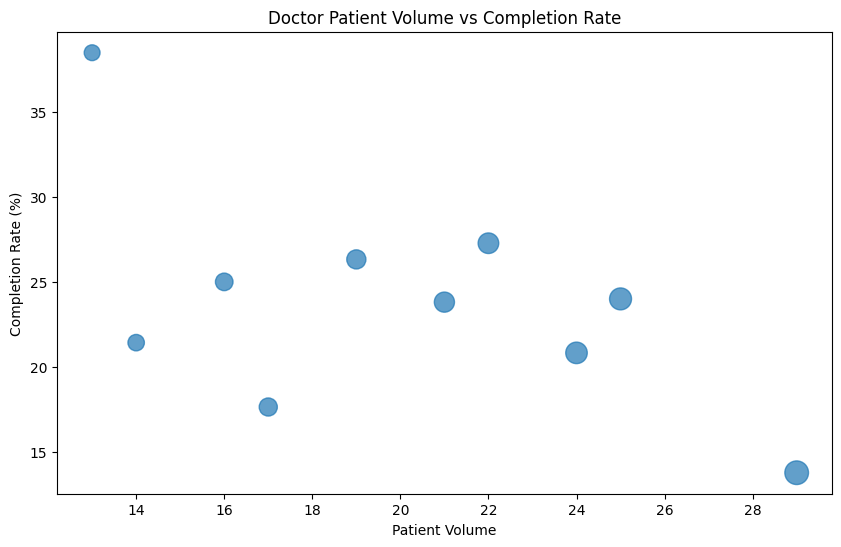

In [0]:
pdf = doctor_analysis.toPandas()

plt.figure(figsize=(10,6))

plt.scatter(
    pdf["Patient_Volume"],
    pdf["Completion_Rate"],
    s=pdf["Patient_Volume"] * 10,
    alpha=0.7
)

plt.xlabel("Patient Volume")
plt.ylabel("Completion Rate (%)")
plt.title("Doctor Patient Volume vs Completion Rate")

plt.show()

## Predictive Analysis

In [0]:
#Predict whether a patient will attend or miss a scheduled appointment using historical appointment, patient, doctor, and scheduling information, so that the healthcare organization can identify high-risk appointments and take preventive actions such as reminders and follow-ups.

In [0]:
from pyspark.sql import functions as F

appointments_ml = appointments.withColumn(
    "No_Show",
    F.when(F.col("STATUS") == "No-show", 1).otherwise(0)
)

In [0]:
appointments_ml.groupBy("No_Show").count().show()

+-------+-----+
|No_Show|count|
+-------+-----+
|      1|   52|
|      0|  148|
+-------+-----+



###### Create the ML Dataframe

In [0]:
ml_data = (
    appointments
    .join(
        patients,
        "PATIENT_ID",
        "left"
    )
    .join(
        doctors,
        "DOCTOR_ID",
        "left"
    )
)

In [0]:
ml_data = ml_data.select(
    "APPOINTMENT_ID",
    "PATIENT_ID",
    "DOCTOR_ID",
    "APPOINTMENT_DATE",
    "APPOINTMENT_TIME",
    "REASON_FOR_VISIT",
    "STATUS",
    "GENDER",
    "DATE_OF_BIRTH",
    "REGISTRATION_DATE",
    "INSURANCE_PROVIDER",
    "SPECIALIZATION",
    "YEARS_EXPERIENCE",
    "HOSPITAL_BRANCH"
)

In [0]:
# Craete Patient Age
ml_data = ml_data.withColumn(
    "Age",
    F.floor(
        F.datediff(
            F.col("APPOINTMENT_DATE"),
            F.col("DATE_OF_BIRTH")
        ) / 365.25
    )
)

In [0]:
# Registration --> Appointment Days
ml_data = ml_data.withColumn(
    "Registration_to_Appointment_Days",
    F.datediff(
        F.col("APPOINTMENT_DATE"),
        F.col("REGISTRATION_DATE")
    )
)

In [0]:
# Appointment Time Features
ml_data = ml_data.withColumn(
    "Appointment_Hour",
    F.hour("APPOINTMENT_TIME")
)

In [0]:
# Appointment Day and Month
ml_data = ml_data.withColumn(
    "Appointment_Day",
    F.date_format("APPOINTMENT_DATE", "EEEE")
)

ml_data = ml_data.withColumn(
    "Appointment_Month",
    F.month("APPOINTMENT_DATE")
)

In [0]:
# Create Target
ml_data = ml_data.withColumn(
    "No_Show",
    F.when(F.col("STATUS") == "No-show", 1).otherwise(0)
)
ml_data = ml_data.drop("STATUS")

In [0]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml import Pipeline

In [0]:
# Categorical Columns
categorical_cols = [
    "GENDER",
    "INSURANCE_PROVIDER",
    "REASON_FOR_VISIT",
    "SPECIALIZATION",
    "HOSPITAL_BRANCH",
    "Appointment_Day"
]
# Numerical Columns
numeric_cols = [
    "Age",
    "YEARS_EXPERIENCE",
    "Registration_to_Appointment_Days",
    "Appointment_Hour",
    "Appointment_Month"
]
# Create Indexes
indexers = [
    StringIndexer(
        inputCol=c,
        outputCol=c + "_Index",
        handleInvalid="keep"
    )
    for c in categorical_cols
]
# One hot Encoding
encoder = OneHotEncoder(
    inputCols=[c + "_Index" for c in categorical_cols],
    outputCols=[c + "_Encoded" for c in categorical_cols]
)
# Assemble features
assembler = VectorAssembler(
    inputCols=
        [c + "_Encoded" for c in categorical_cols]
        + numeric_cols,
    outputCol="features"
)


In [0]:
train_data = ml_data.filter(
    F.col("APPOINTMENT_DATE") < "2026-01-01"
)

test_data = ml_data.filter(
    F.col("APPOINTMENT_DATE") >= "2026-01-01"
)

In [0]:
from pyspark.sql import functions as F
from datetime import timedelta

# Get date range
date_range = ml_data.select(
    F.min("APPOINTMENT_DATE").alias("min_date"),
    F.max("APPOINTMENT_DATE").alias("max_date")
).collect()[0]

min_date = date_range["min_date"]
max_date = date_range["max_date"]

# Calculate 80% of the time period
total_days = (max_date - min_date).days
split_days = int(total_days * 0.80)

split_date = min_date + timedelta(days=split_days)

print("Minimum Date:", min_date)
print("Maximum Date:", max_date)
print("Split Date:", split_date)

Minimum Date: 2023-01-01
Maximum Date: 2023-12-30
Split Date: 2023-10-18


In [0]:
# Create Train and Test Split
train_data = ml_data.filter(
    F.col("APPOINTMENT_DATE") <= F.lit(split_date)
)

test_data = ml_data.filter(
    F.col("APPOINTMENT_DATE") > F.lit(split_date)
)

print("Total:", ml_data.count())
print("Train:", train_data.count())
print("Test:", test_data.count())

Total: 200
Train: 161
Test: 39


In [0]:
print("Training target:")
train_data.groupBy("No_Show").count().show()

print("Testing target:")
test_data.groupBy("No_Show").count().show()

Training target:
+-------+-----+
|No_Show|count|
+-------+-----+
|      1|   41|
|      0|  120|
+-------+-----+

Testing target:
+-------+-----+
|No_Show|count|
+-------+-----+
|      1|   11|
|      0|   28|
+-------+-----+



In [0]:
from pyspark.sql import functions as F

class_counts = train_data.groupBy("No_Show").count()

total_train = train_data.count()

class_counts = class_counts.withColumn(
    "weight",
    F.lit(total_train) /
    (F.lit(2) * F.col("count"))
)

class_counts.show()

+-------+-----+------------------+
|No_Show|count|            weight|
+-------+-----+------------------+
|      1|   41|1.9634146341463414|
|      0|  120|0.6708333333333333|
+-------+-----+------------------+



In [0]:
train_weighted = train_data.join(
    class_counts.select("No_Show", "weight"),
    on="No_Show",
    how="left"
)
train_weighted.select(
    "No_Show",
    "weight"
).groupBy(
    "No_Show",
    "weight"
).count().show()

+-------+------------------+-----+
|No_Show|            weight|count|
+-------+------------------+-----+
|      0|0.6708333333333333|  120|
|      1|1.9634146341463414|   41|
+-------+------------------+-----+



In [0]:
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="No_Show",
    numTrees=100,
    seed=42
)

In [0]:
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="No_Show",
    weightCol="weight",
    numTrees=200,
    maxDepth=5,
    seed=42
)

In [0]:
pipeline = Pipeline(
    stages=indexers + [encoder, assembler, rf]
)

In [0]:
model = pipeline.fit(train_weighted)

predictions = model.transform(test_data)

In [0]:
model_path = "/Volumes/dbacademy/default/tutorials/healthcare_no_show_model"
model.write().overwrite().save(model_path)

In [0]:
predictions.groupBy(
    "No_Show",
    "prediction"
).count().orderBy(
    "No_Show",
    "prediction"
).show()

+-------+----------+-----+
|No_Show|prediction|count|
+-------+----------+-----+
|      0|       0.0|   27|
|      0|       1.0|    1|
|      1|       0.0|   10|
|      1|       1.0|    1|
+-------+----------+-----+



In [0]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

accuracy = MulticlassClassificationEvaluator(
    labelCol="No_Show",
    predictionCol="prediction",
    metricName="accuracy"
).evaluate(predictions)

f1 = MulticlassClassificationEvaluator(
    labelCol="No_Show",
    predictionCol="prediction",
    metricName="f1"
).evaluate(predictions)

print("Accuracy:", round(accuracy, 4))
print("F1 Score:", round(f1, 4))

Accuracy: 0.7179
F1 Score: 0.6398


In [0]:
from pyspark.sql import functions as F

tp = predictions.filter(
    (F.col("No_Show") == 1) &
    (F.col("prediction") == 1)
).count()

fp = predictions.filter(
    (F.col("No_Show") == 0) &
    (F.col("prediction") == 1)
).count()

fn = predictions.filter(
    (F.col("No_Show") == 1) &
    (F.col("prediction") == 0)
).count()

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0

f1_no_show = (
    2 * precision * recall / (precision + recall)
    if (precision + recall) > 0 else 0
)

print("No-show Precision:", round(precision, 4))
print("No-show Recall:", round(recall, 4))
print("No-show F1:", round(f1_no_show, 4))

No-show Precision: 0.5
No-show Recall: 0.0909
No-show F1: 0.1538


In [0]:
cm = predictions.groupBy(
    "No_Show",
    "prediction"
).count().collect()

tp = 0
fn = 0

for row in cm:
    if row["No_Show"] == 1 and row["prediction"] == 1:
        tp = row["count"]
    elif row["No_Show"] == 1 and row["prediction"] == 0:
        fn = row["count"]

recall = tp / (tp + fn) if (tp + fn) > 0 else 0

print("No-show Recall:", round(recall, 4))

No-show Recall: 0.0909


In [0]:
# Logistics Regression
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(
    featuresCol="features",
    labelCol="No_Show",
    weightCol="weight",
    maxIter=100
)
lr_pipeline = Pipeline(
    stages=indexers + [encoder, assembler, lr]
)
# Train Data
lr_model = lr_pipeline.fit(train_weighted)

lr_predictions = lr_model.transform(test_data)
lr_predictions.groupBy(
    "No_Show",
    "prediction"
).count().orderBy(
    "No_Show",
    "prediction"
).show()

+-------+----------+-----+
|No_Show|prediction|count|
+-------+----------+-----+
|      0|       0.0|   14|
|      0|       1.0|   14|
|      1|       0.0|    8|
|      1|       1.0|    3|
+-------+----------+-----+



In [0]:
# Model Evaluation
accuracy_lr = MulticlassClassificationEvaluator(
    labelCol="No_Show",
    predictionCol="prediction",
    metricName="accuracy"
).evaluate(lr_predictions)

f1_lr = MulticlassClassificationEvaluator(
    labelCol="No_Show",
    predictionCol="prediction",
    metricName="f1"
).evaluate(lr_predictions)

print("Logistic Regression Accuracy:", round(accuracy_lr, 4))
print("Logistic Regression F1:", round(f1_lr, 4))

Logistic Regression Accuracy: 0.4359
Logistic Regression F1: 0.4625


In [0]:
tp = lr_predictions.filter(
    (F.col("No_Show") == 1) &
    (F.col("prediction") == 1)
).count()

fp = lr_predictions.filter(
    (F.col("No_Show") == 0) &
    (F.col("prediction") == 1)
).count()

fn = lr_predictions.filter(
    (F.col("No_Show") == 1) &
    (F.col("prediction") == 0)
).count()

precision_lr = tp / (tp + fp) if (tp + fp) > 0 else 0
recall_lr = tp / (tp + fn) if (tp + fn) > 0 else 0

f1_no_show_lr = (
    2 * precision_lr * recall_lr /
    (precision_lr + recall_lr)
    if (precision_lr + recall_lr) > 0 else 0
)

print("No-show Precision:", round(precision_lr, 4))
print("No-show Recall:", round(recall_lr, 4))
print("No-show F1:", round(f1_no_show_lr, 4))

No-show Precision: 0.1765
No-show Recall: 0.2727
No-show F1: 0.2143


Random Forest Accuracy: 71.79%
Random Forest Overall F1: 63.98%
Random Forest No-show Precision: 50.00%
Random Forest No-show Recall: 9.09%
Random Forest No-show F1: 15.38%
Logistic Regression Accuracy: 43.59%
Logistic Regression Overall F1: 46.25%
Logistic Regression No-show Precision: 17.65%
Logistic Regression No-show Recall: 27.27%
Logistic Regression No-show F1: 21.43%

In [0]:
# Re-read from source to refresh DataFrame metadata
appointments = spark.read \
    .option("header", True) \
    .option("inferSchema", True) \
    .csv("/Volumes/dbacademy/default/tutorials/appointments.csv")

patients = spark.read \
    .option("header", True) \
    .option("inferSchema", True) \
    .csv("/Volumes/dbacademy/default/tutorials/patients.csv")

doctors = spark.read \
    .option("header", True) \
    .option("inferSchema", True) \
    .csv("/Volumes/dbacademy/default/tutorials/doctors.csv")

treatments = spark.read \
    .option("header", True) \
    .option("inferSchema", True) \
    .csv("/Volumes/dbacademy/default/tutorials/treatments.csv")

billing = spark.read \
    .option("header", True) \
    .option("inferSchema", True) \
    .csv("/Volumes/dbacademy/default/tutorials/billing.csv")

appointments.write.mode("overwrite").parquet(
    "/Volumes/dbacademy/default/tutorials/parquet/appointments"
)

doctors.write.mode("overwrite").parquet(
    "/Volumes/dbacademy/default/tutorials/parquet/doctors"
)

treatments.write.mode("overwrite").parquet(
    "/Volumes/dbacademy/default/tutorials/parquet/treatments"
)

billing.write.mode("overwrite").parquet(
    "/Volumes/dbacademy/default/tutorials/parquet/billing"
)
patients.write.mode("overwrite").parquet(
    "/Volumes/dbacademy/default/tutorials/parquet/patients"
)

print("Successfully wrote 5 DataFrames to parquet format")


Successfully wrote 5 DataFrames to parquet format
